---
title: "A Gentle Guide to Intersection over Union (IoU)"
description: "IoU is required for evaluating object detection models. But it can be a be tricky to get started with. This tutorial fixes that."
author: "Daniel Bourke"
date: "2025-04-17"
categories: [object detection, data, computer vision, ml, ml projects]
image: "images/iou-blog-post-cover.jpg"
toc: true
toc-depth: 3
toc-expand: 3 # expand table of contents to multiple levels
notebook-links: global
---

<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/learn-ml/blob/main/posts/a-gentle-guide-to-intersection-over-union/index.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Introduction

Welcome to a gentle introduction to IoU!

If you've ever worked on an object detection or localization task, you'll have likely ran into IoU.

And if you haven't, well, that's okay!

The goal of this post is to be a one stop shop for learning about IoU.

The code below is designed to be concise enough to get the idea but also compatible enough to perform your own IoU caculations if needed.

Anyway, enough intro, let's get into it!



## What is IoU?

IoU stands for Intersection over Union.

In full, it's referred to as Area of Intersection over Area of Union.

In object detection tasks, IoU a way to measure how much a one bounding box overlaps another bounding box.

Or said another way, "How much does this prediction box overlap the ground truth box?".

A perfect prediction box (100% overlap with the ground truth box) will have an IoU of 1.0.

A prediction box with no overlap of the ground truth box will have an IoU of 0.0.

In essence, a higher IoU score is better.

![By the end of this post, we'll have replicated this plot as well as learned about how the IoU calculation works in regards to a reference box. As you can see as the IoU score gets higher, the example boxes get closer to the reference box.](./images/multiple_boxes_with_iou_on_real_image.png)


## When does IoU get used?

When evaluating an object detection model, you might see metrics such as mAP@0.5 or mAP@0.75.

These measure the mean average precision (mAP) at an IoU threshold of 0.5 and 0.75 respectively.

An IoU threshold of 0.5 means all predicted boxes with an IoU score of less than 0.5 will be discarded during metric calculation.

And the same goes for an IoU threshold of 0.75, all prediction boxes with IoU score of less than 0.75 will be discarded during mAP calculation.

If you needed an object detection model which is very performant (predicts boxes very close to the ground truth box) you might pay close to attention the mAP metric at a higher IoU threshold.

![Whenever you see an object detection model evaluated with the mAP (Mean Average Precision) metric, chances are IoU played a part. IoU is used as a threshold for different boxes, for example, using an IoU threshold of 0.5 means all predicted boxes with an IoU score of less than 0.5 will be ignored when calculating mAP. Top image is from the [COCO (Common Objects in Context, a large open-source object detection dataset) evaluation website](https://cocodataset.org/#detection-eval), bottom left is from the [Yolov12](https://github.com/sunsmarterjie/yolov12) (a popular kind of object detection model) paper and the bottom right image is from the [RF-DETR (an object source object detection model) GitHub repo](https://github.com/roboflow/rf-detr). Green highlights indicate where IoU has been used. ](./images/where-iou-is-used.png)

## Key terms

* **Object detection** - The practice of trying to localize/detect an object in an image. For example, where is the "dog" in the image?
* **Bounding box** - For the example where is the "dog" in the image, a bounding box would be a rectangle-like box drawn around the dog.
* **Bounding box coordinates** - A set of four numbers depicting the location of a bounding box in an image in relation to the image's height and width. Can come in a number of [different formats](https://www.learnml.io/posts/a-guide-to-bounding-box-formats/) such as `XYXY` or `[x_min, y_min, x_max, y_max]`, the format you use will depend on the data you have/framework you choose.
* **Ground truth box** - A label example of a bounding box around a target item that is known to be correct. For example, it is often a bounding box drawn by a human around an item of interest in an image.
* **Prediction box** - A bounding box produced by model. An ideal prediction box is equivalent to a ground truth box, though is not always the case, poor prediction boxes can be far different to a ground truth box.
* **IoU = Intersection over Union** - A measurement of how well two boxes overlap. For example, comparing a prediction box to a ground truth box. A perfect prediction box (100% overlap with ground truth box) will have an IoU score of 1.0, a prediction box with no overlap with a ground truth box will have an IoU score of 0.0.



## How does IoU get calculated?

### Calculating IoU with pseudocode

Let's start with pseudocode.

When comparing two boxes:

1. `box_1` - Coordinates in `XYXY` format, e.g. `[x_min, y_min, x_max, y_max]`.
2. `box_2` - Coordinates in `XYXY` format, e.g. `[x_min, y_min, x_max, y_max]`

> **Note:** This post assumes your bounding box coordinates are in `XYXY` format and have absolute coordinates. For a guide to different bounding box formats, see [*A Guide to Bounding Box Formats and How to Draw Them*](https://www.learnml.io/posts/a-guide-to-bounding-box-formats/).

The **area of intersection** is calculated by taking the maximum of the minimum x and y coordinates (e.g. `max(x_min_box_1, x_min_box_2)` and `max(y_min_box_1, y_min_box_2)`).

And the minimum of the maximum x and y coordinates (e.g. `min(x_max_box_1, x_max_box_2)` and `min(y_max_box_1, y_max_box_2)`).

```
# Find the intersection box coordinates in XYXY
intersection_box_x_min = max(x_min_box_1, x_min_box_2)
intersection_box_y_min = max(y_min_box_1, y_min_box_2)
intersection_box_x_max = min(x_max_box_1, x_max_box_2)
intersection_box_y_max = min(y_max_box_1, y_max_box_2)

intersection_box_xyxy = [intersection_box_x_min,
                         intersection_box_y_min,
                         intersection_box_x_max,
                         intersection_box_y_max]

# Find height and width for area (must be non-zero to have value)
intersection_height = max(0, intersection_y_max - intersection_y_min)
intersection_width = max(0, intersection_x_max - intersection_x_min)

# Find the area of intersection (note: this may be 0 if the boxes don't overlap)
intersection_area = intersection_height * intersection_width
```

The result of these aggregations are the `XYXY` coordinates of the intersection box.

The intersection area can then be found by multiplying the width and height of the intersection box (note: for intersection area to be non-zero, the width and heights should be positive, i.e. greater than 0).

The **area of union** is calculated by taking the areas of `box_1` and `box_2` and subtracting the **area of intersection**.

```
# Calculate the union area
union_area = box_1_area * box_2_area - intersection_area
```

Finally, we can calculate the IoU by dividing the area of intersection by the area of union.

```
# Find the IoU score
iou = intersection_area / union_area
```

Of course, the area of intersection may be zero, resulting in an IoU score of 0.0.

### Calculating IoU with math

$$IoU = \frac{\text{Area of Intersection}}{\text{Area of Union}} = \frac{|A \cap B|}{|A \cup B|} = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}$$

Where:

* $A$ is a bounding box in the same format as $B$.
* $∩$ means the overlapping space (intersection).
* $∪$ means the combined space (union).


## Part 1 - Exploring IoU with synthetic boxes

Before we get onto drawing bounding boxes on real images, let's practice by creating synthetic boxes and plotting them with `matploblib`.

### Creating a dataclass to store box coordinates

One the most important concepts when it comes to object detection is the format your boxes are in.

They could be `XYXY`, `XYWH`, `CXCYWH`, normalized or absolute (see [*A Guide to Bounding Box Formats and How to Draw Them*](https://www.learnml.io/posts/a-guide-to-bounding-box-formats/) for more on this).

To keep things consistent let's make a Python [`@dataclass`](https://docs.python.org/3/library/dataclasses.html) to store our box coordinates.

We'll use `XYXY` (`x_min`, `y_min`, `x_max`, `y_max`) format with absolute values.

> **Note:** Python dataclasses are very helpful to ensure a particular structure of data. As you'll see, we can also implement checks and helpful methods/attributes to go along with our data structures.

In [1]:
# Implementing a dataclass to store our box coordinates
from dataclasses import dataclass, astuple

@dataclass
class Box:
  """Dataclass for holding a set of individual bounding box coordinates in absolute XYXY format."""
  x_min: float
  y_min: float
  x_max: float
  y_max: float

  # Make a check after initializing an instance of Box
  def __post_init__(self):
    self._check_box_coordinate_ordering()

  # Implement a check to make sure box obeys x1 < x2 and y1 < y2 (otherwise box will be negative coordinates)
  # Having a dataclass do this means we can ensure valid boxes, preventing downstream errors
  def _check_box_coordinate_ordering(self):
    """Checks to make sure x_max > x_min and y_max > y_min"""
    if self.x_min >= self.x_max:
      raise ValueError(f"x_min ({self.x_min}) must be less than x_max ({self.x_max})")
    if self.y_min >= self.y_max:
      raise ValueError(f"y_min ({self.y_min}) must be less than y_max ({self.y_max})")

  # Add properites to the dataclass for easy access
  @property
  def width(self):
    return self.x_max - self.x_min

  @property
  def height(self):
    return self.y_max - self.y_min

  @property
  def area(self):
    return self.width * self.height

  @property
  def max_coordinate_value(self):
    return max(self.x_min, self.x_max, self.y_min, self.y_max)

  @property
  def min_coordinate_value(self):
    return min(self.x_min, self.x_max, self.y_min, self.y_max)

Beautiful!

Now let's make an example box and inspect its properties.

In [2]:
# Make an example box
example_box = Box(x_min=100.0,
                  y_min=100.0,
                  x_max=200.0,
                  y_max=200.0)

# Get properties
# Using a dataclass helps make accessing these properties easy
example_box_height = example_box.height
example_box_width = example_box.width
example_box_area = example_box.area

# Inspect values
print(f"[INFO] Example box (XYXY format): {example_box}")
print(f"[INFO] Example box height: {example_box_height}")
print(f"[INFO] Example box width: {example_box_width}")
print(f"[INFO] Example box area: {example_box_area}")

[INFO] Example box (XYXY format): Box(x_min=100.0, y_min=100.0, x_max=200.0, y_max=200.0)
[INFO] Example box height: 100.0
[INFO] Example box width: 100.0
[INFO] Example box area: 10000.0


### Calculate IoU between two boxes: step by step

Our IoU formula is:

$$IoU = \frac{\text{Area of Intersection}}{\text{Area of Union}} = \frac{|A \cap B|}{|A \cup B|} = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}$$

**Area of Intersection** is where the two boxes overlap.

**Area of Union** is the combined box space minus the Area of Intersection (Area of Box 1 + Area of Box 2 - Area of Intersection).

To practice calculating IoU, we'll calculate the IoU of two boxes:

* `box_1` - We'll consider this our ground truth box.
* `box_2` - We'll consider this a box predicted by our model.

Why a ground truth box and a prediction box?

Because IoU values are usually calculated between ground truth and prediction boxes to measure **how well a prediction captures a ground truth label**.

In [3]:
# Create box_1 - this will be our ground truth box
box_1 = Box(x_min=50,
            y_min=50,
            x_max=150,
            y_max=150) # Boxes are in XYXY format

# Create box_2 - this is an example prediction box that is very close to the ground truth
box_2 = Box(x_min=51,
            y_min=51,
            x_max=151,
            y_max=151) # Area of box_2 is the same as box_1 but it is off by 1 pixel on x & y

# Calculate IoU by hand

# Step 1: Area of Intersection

# Get max values of min coordinates
x_min_intersection = max(box_1.x_min, box_2.x_min)
y_min_intersection = max(box_1.y_min, box_2.y_min)

# Get min values of max coordinates
x_max_intersection = min(box_1.x_max, box_2.x_max)
y_max_intersection = min(box_1.y_max, box_2.y_max)

# Get width and height of intersection box (make sure they are 0 or positive values)
intersection_width = max(0, x_max_intersection - x_min_intersection)
intersection_height = max(0, y_max_intersection - y_min_intersection)

# Calculate the intersection area
intersection_area = intersection_width * intersection_height

# Step 2: Area of Union
# Note: This is where properties of our Box dataclass come in handy
union_area = box_1.area + box_2.area - intersection_area

# Step 3: Calculate IoU
iou = intersection_area / union_area
iou

0.9609765663300324

We get an IoU score of `0.961`, which means the boxes overlap quite substantially (a perfect overlap would mean an IoU of `1.0`).

Let's functionize our IoU code so we can reuse it later.

### Creating a function to calculate the IoU of two boxes

Rather than write out IoU calculations by hand each time, let's make a function to do it for us.

We'll also add the functionality to return the coordinates of the intersection box (if there is one) so we can plot it if we like.

In [4]:
def calculate_iou(box_1: Box,
                  box_2: Box,
                  return_intersection_box: bool = False) -> float:
  """Calculates the IoU (Intersection over Union) value for two bounding boxes.

  Boxes are expected to be in XYXY format with absolute pixel values.

  Args:
    box_1 (Box) - An instance of the dataclass Box which contains bounding box
      coordinates in XYXY format with absolute values.
    box_2 (Box) - An instance of the dataclass Box which contains bounding box
      coordinates in XYXY format with absolute values.
    return_intersection_box (bool, optional) - Whether to return the intersection
      bounding box, useful for visulization. Defaults to False.

  Returns:
    iou (float) - A floating point value of the IoU score between box_1 and box_2,
      if there is no overlap, will return 0.
    intersection_box (Box, optional) - An instance of the dataclass Box which contains bounding box
      coordinates in XYXY format with absolute values for the intersecting box between box_1 and box_2.
      May return None if there is no intersecting box.
  """

  # Step 1: Calculate intersection coordinates and intersection area
  x_min_intersection = max(box_1.x_min, box_2.x_min)
  y_min_intersection = max(box_1.y_min, box_2.y_min)

  x_max_intersection = min(box_1.x_max, box_2.x_max)
  y_max_intersection = min(box_1.y_max, box_2.y_max)

  # Get width and height of intersection box (make sure these are positive values or 0)
  intersection_width = max(0, x_max_intersection - x_min_intersection)
  intersection_height = max(0, y_max_intersection - y_min_intersection)

  # Find the Area of Intersection
  intersection_area = intersection_width * intersection_height

  # Step 2: Find the union area
  union_area = box_1.area + box_2.area - intersection_area

  # Step 3: Calculate the IoU score
  iou = round(intersection_area / union_area, 3)

  # Add in an option to return the intersection box
  if return_intersection_box:
    if intersection_area > 0:
      intersection_box = Box(x_min=x_min_intersection,
                             y_min=y_min_intersection,
                             x_max=x_max_intersection,
                             y_max=y_max_intersection)
      return iou, intersection_box
    else:
      # If intersection area is not over 0, there is no intersection box
      return iou, None

  return iou

# Test out our function
iou, intersection_box = calculate_iou(box_1=box_1,
                                      box_2=box_2,
                                      return_intersection_box=True)

print(f"[INFO] IoU between box_1 and box_2: {iou:.3f}")
print(f"[INFO] Intersection box between box_1 and box_2: {intersection_box}")

[INFO] IoU between box_1 and box_2: 0.961
[INFO] Intersection box between box_1 and box_2: Box(x_min=51, y_min=51, x_max=150, y_max=150)


### Getting visual: Plotting two bounding boxes on top of each other

Ok we've found the IoU score for two boxes.

But since object detection is often a computer vision problem, let's see how they *look*.

We'll follow the data explorer's motto of *visualize, visualize, visualize!*

Let's start by creating a small helper function to find the centre of an `XYXY` box (this will help with visualization).

In [5]:
# Quick helper function to get the center of a box
def get_center_coordinates(box: Box) -> tuple[float, float]:
  """Gets center coordinates of a XYXY box and returns them as (center_x, center_y)"""
  center_x = box.x_min + (0.5 * box.width)
  center_y = box.y_min + (0.5 * box.height)

  return (center_x, center_y)

Nice!

Now we can use our `calculate_iou` function along with some [`matplotlib.patches.Rectangle`](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html) instances to help us visualize our synthetic boxes.

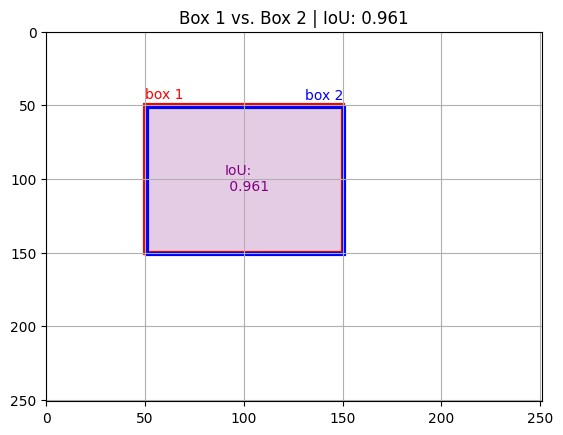

In [6]:
# Write code to plot box_1 and box_2 and highlight the IoU value
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_two_boxes_with_iou(box_1: Box, box_2: Box):

  # Calculate the IoU
  iou, intersection_box = calculate_iou(box_1=box_1,
                                        box_2=box_2,
                                        return_intersection_box=True)

  # Create figure and axes
  fig, ax = plt.subplots()

  # Create a Rectangle patch for box_1
  # See docs: https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html
  rectangle_1 = Rectangle(xy=(box_1.x_min, box_1.y_min),
                          width=box_1.width,
                          height=box_1.height,
                          linewidth=3,
                          edgecolor="r",
                          facecolor="none")
  # Add text for box label, see docs: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html
  ax.text(x=box_1.x_min,
          y=box_1.y_min - 5,
          s="box 1",
          color="r")

  # Create a Rectangle patch for box_2
  rectangle_2 = Rectangle(xy=(box_2.x_min, box_2.y_min),
                          width=box_2.width,
                          height=box_2.height,
                          linewidth=3,
                          edgecolor="b",
                          facecolor="none")
  ax.text(x=box_2.x_max - 20,
          y=box_2.y_min - 5,
          s="box 2",
          color="b")

  # Create a Rectangle patch for the intersection box
  if intersection_box:
    rectangle_intersection = Rectangle(xy=(intersection_box.x_min, intersection_box.y_min),
                                      width=intersection_box.width,
                                      height=intersection_box.height,
                                      linewidth=1,
                                      edgecolor="purple",
                                      facecolor="purple",
                                      alpha=0.2)
    ax.add_patch(rectangle_intersection)

    # Get center coordinates of intersection box for visualizing text
    intersection_center_x, intersection_center_y = get_center_coordinates(box=intersection_box)

    # Plot IoU text in center of IoU box
    ax.text(x=intersection_center_x - 10, # adjust coordinates slightly for better centering
            y=intersection_center_y + 7.5,
            s=f"IoU:\n {round(iou, 3)}",
            color="purple")

  # Add the rectangles to the plot
  ax.add_patch(rectangle_1)
  ax.add_patch(rectangle_2)

  # Set the limits of the plot (adjust as needed to see your rectangle)
  max_dim = max(box_1.max_coordinate_value, box_2.max_coordinate_value) + 100
  ax.set_xlim(left=0, right=max_dim)
  ax.set_ylim(bottom=max_dim, top=0)

  # Add a title
  plt.title(f"Box 1 vs. Box 2 | IoU: {round(iou, 3)}")

  # Show the grid
  plt.grid(True)

  # Display the plot
  plt.show()

plot_two_boxes_with_iou(box_1=box_1, box_2=box_2)

Woah!

Now that's one good looking plot.

How about we do the same but for a few more boxes?

### Plotting multiple boxes at different IoU levels

So far `box_1` and `box_2` have overlapped quite a bit.

To expand our horizons, let's create multiple boxes to visualize the IoU calculation with different levels of overlap.

We'll create these in comparison to the ground truth `box_1`.

Feel free to change the values below as you please.

In [7]:
# Low IoU box (50 pixels across and down from box_1)
box_3 = Box(x_min=100,
            y_min=100,
            x_max=200,
            y_max=200)

# No IoU box (no overlap with box_1)
box_4 = Box(x_min=150,
            y_min=150,
            x_max=250,
            y_max=250)

box_3, box_4

(Box(x_min=100, y_min=100, x_max=200, y_max=200),
 Box(x_min=150, y_min=150, x_max=250, y_max=250))

Two new boxes created!

Now how do `box_3` and `box_4` compare to `box_1`?

In [8]:
# Calculate IoU
box_1_vs_box_3_iou = calculate_iou(box_1=box_1, box_2=box_3)
box_1_vs_box_4_iou = calculate_iou(box_1=box_1, box_2=box_4)

print(f"[INFO] Box 1 and Box 3 IoU: {box_1_vs_box_3_iou}")
print(f"[INFO] Box 1 and Box 4 IoU: {box_1_vs_box_4_iou}")

[INFO] Box 1 and Box 3 IoU: 0.143
[INFO] Box 1 and Box 4 IoU: 0.0


Wonderful!

Let's plot these in a similar way to before.

We'll consider `box_1` the ground truth and compare `box_2`, `box_3` and `box_4` to it as example predictions (we'll also compare `box_1` to itself as a baseline).

mkdir: images: File exists


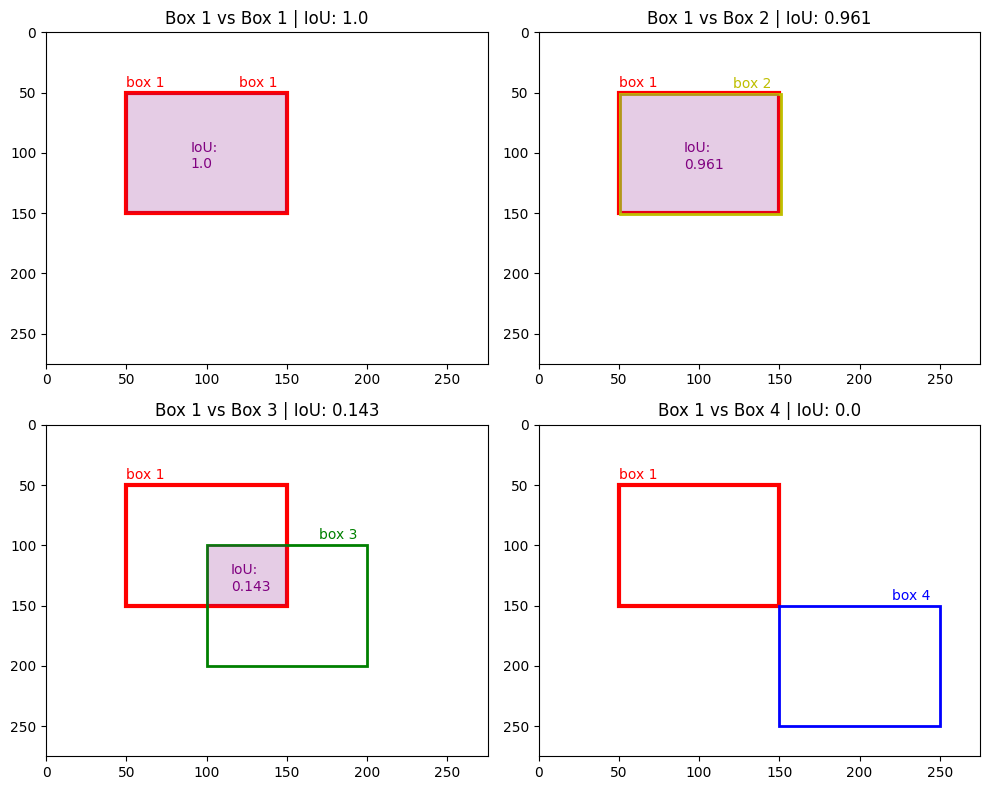

In [9]:
# Plot all boxes and their IoUs against box_1

# Want to compare all boxes against box_1 (including itself)
box_list = [box_1, box_2, box_3, box_4]

# Make colour dictionary to differentiate boxes
box_colours = ["r", "y", "g", "b"]

# Create a series of subplots we can plot our comparisons on
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = ax.flatten()

# Loop through boxes and plot them on the axes
for i, box_i in enumerate(box_list):
  ax_current = axes[i]

  # Calculate IoU and intersection box coordinates
  iou, intersection_box = calculate_iou(box_1=box_1,
                                        box_2=box_i,
                                        return_intersection_box=True)

  # Plot ground truth box (box_1)
  box_1_rect = Rectangle(xy=(box_1.x_min,
                             box_1.y_min),
                         width=box_1.width,
                         height=box_1.height,
                         linewidth=3,
                         edgecolor="r",
                         facecolor="none")
  ax_current.add_patch(box_1_rect)
  ax_current.text(x=box_1.x_min,
                  y=box_1.y_min - 5,
                  s="box 1",
                  color="red")

  # Plot target comparison box (box_i)
  box_i_rect = Rectangle(xy=(box_i.x_min,
                             box_i.y_min),
                         width=box_i.width,
                         height=box_i.height,
                         linewidth=2,
                         edgecolor=box_colours[i],
                         facecolor="none")
  ax_current.add_patch(box_i_rect)
  ax_current.text(x=box_i.x_max - 30,
                  y=box_i.y_min - 5,
                  s=f"box {i+1}",
                  color=box_colours[i])

  # Add text + IoU overlay (if the IoU value exists)
  if iou > 0:
    intersection_rect = Rectangle(xy=(intersection_box.x_min,
                                      intersection_box.y_min),
                                  width=intersection_box.width,
                                  height=intersection_box.height,
                                  linewidth=0,
                                  edgecolor="purple",
                                  facecolor="purple",
                                  alpha=0.2)
    ax_current.add_patch(intersection_rect)

    # Add IoU text
    intersection_center_x, intersection_center_y = get_center_coordinates(box=intersection_box)
    ax_current.text(x=intersection_center_x - 10,
                    y=intersection_center_y + 12.5, # adjust center slightly to get better alignment
                    s=f"IoU:\n{iou}",
                    color="purple")

  # Set axis limits (required, otherwise will default to 0-1)
  ax_current.set_xlim(left=0, right=275)
  ax_current.set_ylim(bottom=275, top=0)

  # Add title to each axis
  ax_current.set_title(f"Box 1 vs Box {i+1} | IoU: {iou}")

plt.tight_layout()

# Optional: save the figure for later use
!mkdir images
plt.savefig("images/multiple_boxes_with_iou_plot.png") 

# Show the plot
plt.show()

Ok ok, we're starting to get places!

We've seen four different boxes and their various IoU scores.

But in reality you'll often inspect/evaluate boxes at several levels of IoU threshold.

Let's see what different IoU thresholds look like against our ground truth box in the next section.

## Section 2 - Plotting multiple boxes at various IoU thresholds

IoU scores can be influenced by several factors including the prediction box being too small, too big or the right size but unaligned.

It's because of this that you'll often see object detection benchmarks such as [COCO (Common Objects in Context)](https://cocodataset.org/#detection-eval) evaluated at several IoU thresholds.

For example, when you see `mAP@0.5:0.95` or `mAP@0.5:0.05:0.95` or often just plain `mAP` (confusing, yes, but all of these often refer to the same thing) it means a combined average of mAP at IoU thresholds from 0.5 to 0.95 stepping 0.05 each time.

In other words:
1. Calculate mAP with IoU threshold 0.5 (all boxes with IoU under 0.5 discarded).
2. Calculate mAP with IoU threshold 0.55 (all boxes with IoU under 0.55 discarded).
3. ...
3. Repeat until 0.95 is reached at steps of 0.05 (0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95).
4. Average the mAP at all thresholds to get the overall mAP.

To visualize IoU at various levels, let's write a function to take in an existing bounding box to use as reference and generate a new bounding box which either grows larger, shrinks or shifts until it reaches a target IoU threshold.

For example, say we input `box_1` and tell it to `"grow"` until it reaches an IoU of 0.5, our function will continue to expand `box_1`'s parameters in a new box until it reaches an IoU of 0.5.

In [10]:
import copy

# Create a list of ways to alter a bounding box
box_alteration_modes = ["grow", "shift", "shrink"]

def generate_box_with_target_iou(reference_box: Box,
                                 target_iou: float,
                                 box_alteration_mode: str) -> tuple[Box, float, Box]:

  assert box_alteration_mode in box_alteration_modes, f"box_alteration_mode must be one of the following: {box_alteration_modes}"

  # Want a way to generate an IoU value that is similar to the target value

  # Create a new box to alter until target IoU is met
  new_box = copy.copy(reference_box)

  # Calculate current IoU
  current_iou, intersection_box = calculate_iou(box_1=reference_box,
                                                box_2=new_box,
                                                return_intersection_box=True)

  # Add a small buffer to the target_iou to ensure IoU scores get over it
  target_iou += 0.03

  # Add step amount for each box change
  step = 1.0 # adjust the new box 1 pixel at a time until it fits the current IoU

  # Adjust box with alteration mode "grow"
  if box_alteration_mode == "grow":
    while current_iou > target_iou and current_iou > 0: # prevent IoU hitting 0
      # Decrease the min values to grow the new box
      new_box.x_min -= step
      new_box.y_min -= step

      # Increase the max values to grow the new box
      new_box.x_max += step
      new_box.y_max += step

      # Recalculate IoU
      current_iou, intersection_box = calculate_iou(box_1=reference_box,
                                                    box_2=new_box,
                                                    return_intersection_box=True)

  # Adjust box with alteration mode "shift"
  if box_alteration_mode == "shift":
    while current_iou > target_iou and current_iou > 0:
      # Shift the box to the right (increase x) without changing the dimensions until IoU is met
      new_box.x_min += step
      new_box.x_max += step

      # Recalculate IoU
      current_iou, intersection_box = calculate_iou(box_1=reference_box,
                                                    box_2=new_box,
                                                    return_intersection_box=True)

  # Adjust box with alteration mode "shrink"
  if box_alteration_mode == "shrink":
    while current_iou > target_iou and current_iou > 0:
      # Increase min values to shrink the new box
      new_box.x_min += step
      new_box.y_min += step

      # Decrease max values to shrink the new box
      new_box.x_max -= step
      new_box.y_max -= step

      # Recalculate IoU
      current_iou, intersection_box = calculate_iou(box_1=reference_box,
                                                    box_2=new_box,
                                                    return_intersection_box=True)

  # Once target_iou is met, return the new box, current IoU score and intersection box
  return new_box, current_iou, intersection_box

# Try out our function
box_alteration_mode = "grow" # <- feel free to change this!
target_iou = 0.5 # <- feel free to change this too!
new_box, iou, intersection_box = generate_box_with_target_iou(reference_box=box_1,
                                                              target_iou=target_iou,
                                                              box_alteration_mode=box_alteration_mode)

# Print the results
print(f"[INFO] Box alteration mode: {box_alteration_mode}")
print(f"[INFO] Target IoU: {0.5} (or higher)")
print(f"[INFO] Input box: {box_1}")
print()
print(f"[INFO] New box: {new_box}")
print(f"[INFO] New IoU: {iou}")
print(f"[INFO] Intersection box: {intersection_box}")

[INFO] Box alteration mode: grow
[INFO] Target IoU: 0.5 (or higher)
[INFO] Input box: Box(x_min=50, y_min=50, x_max=150, y_max=150)

[INFO] New box: Box(x_min=31.0, y_min=31.0, x_max=169.0, y_max=169.0)
[INFO] New IoU: 0.525
[INFO] Intersection box: Box(x_min=50, y_min=50, x_max=150, y_max=150)


Nice!

We've altered `box_1` into `new_box`, now let's see how they look using our `plot_two_boxes_with_iou()` function.

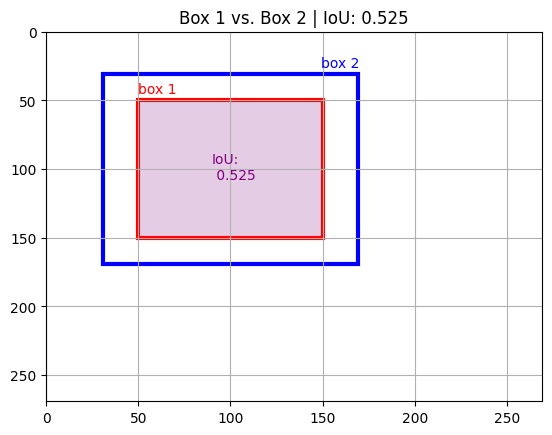

In [11]:
plot_two_boxes_with_iou(box_1=box_1,
                        box_2=new_box)

### Generating synthetic boxes for different IoU thresholds

Okay, we've got a way to generate a synthetic box given an IoU threshold.

How about we generate some boxes for all of the COCO mAP thresholds?

In other words, we'll go from 0.5 to 0.95 stepping 0.05 each time.

```
# COCO mAP IoU thresholds
iou_thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
```

We'll generate a box for each alteration mode too (grow, shift, shrink).

And we'll save all of them to a dictionary so we can visualize them later.

Let's create a function to do so.

In [12]:
import numpy as np
from typing import List, Dict

box_alteration_modes = ["grow", "shift", "shrink"]

def generate_boxes_at_different_iou_thresholds(reference_box: Box,
                                               box_alteration_modes: List[str] = box_alteration_modes) -> Dict:

  # Create series of IoU thresholds
  # This will go from 0.5 -> 0.95 stepping 0.05 at a time (same as COCO thresholds)
  # The round() is to remove artifacts such as 0.7500000002 -> 0.75
  iou_thresholds = [float(round(value, 2)) for value in np.arange(0.5, 1.0, 0.05)]

  # Loop through IoU thresholds and create a series of boxes for each alteration mode
  iou_thresholds_and_boxes = {}
  for iou_threshold in iou_thresholds:
    # Reference box is always IoU = 1.0 of itself
    iou_thresholds_and_boxes[iou_threshold] = {"reference": (reference_box, 1.0)}
    for box_alteration_mode in box_alteration_modes:
      # Generate a new box and get the IoU score for each IoU threshold and box_alteration_mode
      new_box, iou, intersection_box = generate_box_with_target_iou(reference_box=reference_box,
                                                                    target_iou=iou_threshold,
                                                                    box_alteration_mode=box_alteration_mode)
      iou_thresholds_and_boxes[iou_threshold][box_alteration_mode] = (new_box, iou)

  return iou_thresholds_and_boxes

Box generation function ready!

Let's try it out.

In [13]:
# Try out our function
generated_boxes_at_different_iou_thresholds = generate_boxes_at_different_iou_thresholds(reference_box=box_1)

# Print out the generated boxes
for key, value in generated_boxes_at_different_iou_thresholds.items():
  print(f"IoU Threshold: {key}")
  for sub_key, sub_value in value.items():
    print(f"Box type: {sub_key} | Box: {sub_value[0]} | IoU score: {sub_value[1]}")
  print()

IoU Threshold: 0.5
Box type: reference | Box: Box(x_min=50, y_min=50, x_max=150, y_max=150) | IoU score: 1.0
Box type: grow | Box: Box(x_min=31.0, y_min=31.0, x_max=169.0, y_max=169.0) | IoU score: 0.525
Box type: shift | Box: Box(x_min=81.0, y_min=50, x_max=181.0, y_max=150) | IoU score: 0.527
Box type: shrink | Box: Box(x_min=64.0, y_min=64.0, x_max=136.0, y_max=136.0) | IoU score: 0.518

IoU Threshold: 0.55
Box type: reference | Box: Box(x_min=50, y_min=50, x_max=150, y_max=150) | IoU score: 1.0
Box type: grow | Box: Box(x_min=34.0, y_min=34.0, x_max=166.0, y_max=166.0) | IoU score: 0.574
Box type: shift | Box: Box(x_min=77.0, y_min=50, x_max=177.0, y_max=150) | IoU score: 0.575
Box type: shrink | Box: Box(x_min=62.0, y_min=62.0, x_max=138.0, y_max=138.0) | IoU score: 0.578

IoU Threshold: 0.6
Box type: reference | Box: Box(x_min=50, y_min=50, x_max=150, y_max=150) | IoU score: 1.0
Box type: grow | Box: Box(x_min=37.0, y_min=37.0, x_max=163.0, y_max=163.0) | IoU score: 0.63
Box type

Perfect! Now let's write some code to visualize these boxes.

### Visualizing boxes at various IoU thresholds

We know higher IoU is better.

But how much better?

Let's write some visualization code so we can visualize our synthetic boxes across various IoU thresholds.

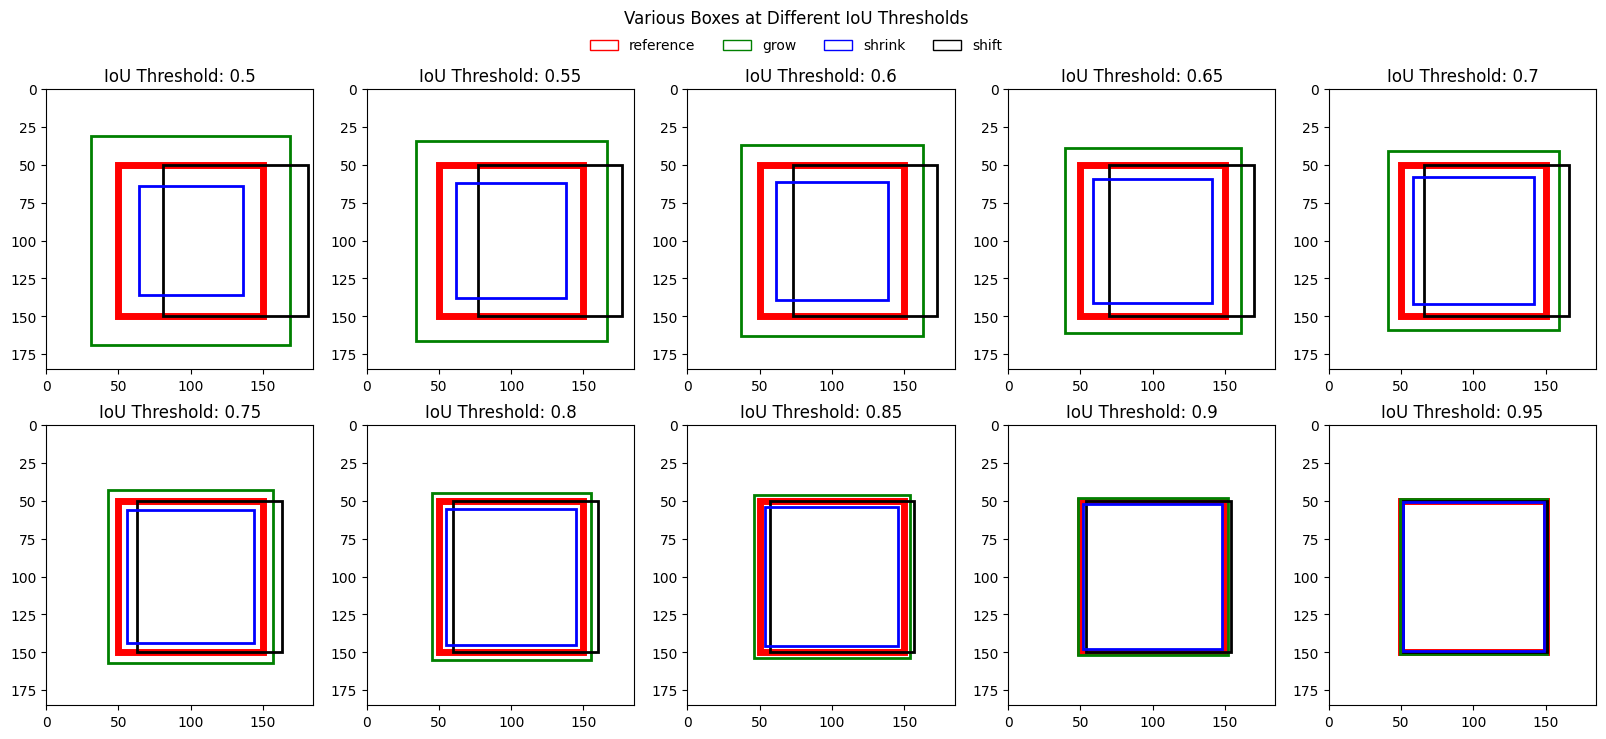

In [14]:
# Plot all boxes with different IoU scores + different alteration modes
from matplotlib.patches import Patch

# Make a dict for box_type -> colour to plot
box_type_colour_dict = {"reference": "red",
                        "grow": "green",
                        "shrink": "blue",
                        "shift": "black"}

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
ax_flatten = ax.flatten()

for i, (iou_threshold, box_dict) in enumerate(generated_boxes_at_different_iou_thresholds.items()):
  ax_current = ax_flatten[i]

  # Plot reference, grow, shift, shrink boxes
  for box_type, box_coordinates_and_iou in box_dict.items():
    box_colour = box_type_colour_dict[box_type] # e.g. "reference" -> red

    box_coordinates = box_coordinates_and_iou[0]

    # Plot the box on the current axis
    box_rectangle = Rectangle(xy=(box_coordinates.x_min, box_coordinates.y_min),
                              width=box_coordinates.width,
                              height=box_coordinates.height,
                              linewidth=5 if box_type == "reference" else 2,
                              facecolor="none",
                              edgecolor=box_colour)
    ax_current.add_patch(box_rectangle)

  # Set the target axis plot title
  ax_current.set_title(f"IoU Threshold: {iou_threshold}")

  # Set the size of the axis so the boxes are visible (they default to be 0 -> 1)
  ax_current.set_xlim(left=0, right=185)
  ax_current.set_ylim(bottom=185, top=0)

# Create a patch legend at the base of the plot
# See docs for Patch: https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html
legend_elements = [Patch(facecolor="none",
                         edgecolor=colour,
                         label=box_type)
                   for box_type, colour in box_type_colour_dict.items()]
fig.legend(handles=legend_elements,
           loc="lower center",
           ncols=len(box_type_colour_dict),
           bbox_to_anchor=(0.5, 0.91), # x, y in percentage of the plot
           frameon=False)

plt.suptitle("Various Boxes at Different IoU Thresholds")
plt.show()

That's a lot of boxes!

Starting at an IoU threshold of 0.5, we can see the green, blue and black boxes don't line up too well with the red (ground truth) box.

But as they progress to 0.8 and onwards, all of the boxes start to converge on the reference.

Depending on your object detection problem you might be able to tolerate a model which scores a higher mAP at an IoU threshold of 0.5 (`mAP@0.5`) but a lower mAP at an IoU threshold of 0.75 (`mAP@0.75`).

If you need an accurate box detection model, you'll want your mAP at higher IoU thresholds to be on par or only slightly lower then lower Iou thresholds.

> **Note:** By default, an object detection model's `mAP@0.5` is generally the highest mAP value it will achieve. This is because far fewer boxes get cut off at the IoU threshold of 0.5 and in turn, there is more chance for a correct prediction. So in general, you should expect mAP to be lower at higher IoU thresholds, however, if you need really good boxes, you don't want this value to be too much lower.

## Part 3 - Calculating IoU scores against a real bounding box

We've seen different IoU calculations for various synthetic boxes.

Time to do the same with a real image and and a real bounding box!





### Getting a real image and real bounding box annotation

We'll use an image from an object detection project I've worked on called [Trashify](https://www.learnhuggingface.com/notebooks/hugging_face_object_detection_tutorial), where the goal is to detect `["bin", "trash", "hand"]` in an image (if all 3 classes are present, you get +1 point) to encourage people to pick up trash in their local area.

The annotations are made using [Prodigy](https://prodi.gy/), a labelling tool (there are many kinds of labelling tools out there, you could even get AI to generate a custom one for you).


In [15]:
import os

image_path = "trashify_demo_image_for_box_format.jpeg"
annotations_path = "trashify_demo_image_annotations.json"

if not os.path.exists(image_path):
    !wget https://raw.githubusercontent.com/mrdbourke/learn-ml/refs/heads/main/posts/a-guide-to-bounding-box-formats/data/trashify_demo_image_for_box_format.jpeg

if not os.path.exists(annotations_path):
    !wget https://raw.githubusercontent.com/mrdbourke/learn-ml/refs/heads/main/posts/a-guide-to-bounding-box-formats/data/trashify_demo_image_annotations.json

Real image and box annotation downloaded!

[INFO] Image size: (960, 1280) (width, height)


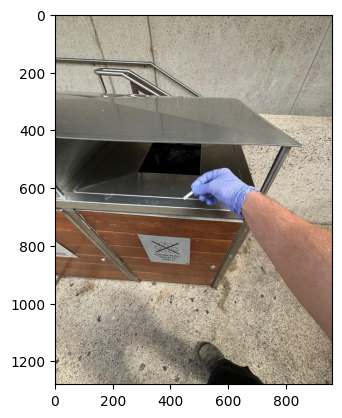

In [16]:
from PIL import Image

loaded_image = Image.open(image_path)
print(f"[INFO] Image size: {loaded_image.size} (width, height)")

# Show the image
plt.imshow(loaded_image);

Awesome, looks like we've got a 960x1280 (width x height) image taken on a iPhone (I know this because I took the image :D).

Now let's inspect the assosciated label file, it's common practice to have a label file in JSON format containing many different annotations.

In our case, our annotation file `"trashify_demo_image_annotations.json"` contains just one annotation.

In [17]:
import json

# Extract single box annotations from the annotations dict
annotations = json.load(open(annotations_path))
annotations

{'image_path': 'trashify_demo_image_for_box_format.jpeg',
 'file_name': '7c9b2934-23bc-46c5-8e9f-c2a66948b653.jpeg',
 'readme': 'Demo image for displaying box formats on. Box coordinates in annotations dict come in absolute XYWH format. Image size is in (height, width) format.',
 'annotations': [{'id': '4226a4fb-12b2-4e16-b29d-b33d667048d1',
   'label': 'bin',
   'color': 'magenta',
   'x': 8.9,
   'y': 275.3,
   'height': 688.7,
   'width': 858.6,
   'center': [438.2, 619.65],
   'type': 'rect',
   'points': [[8.9, 275.3], [8.9, 964], [867.5, 964], [867.5, 275.3]]}],
 'image_size': [1280, 960]}

Wonderful, it looks like we get our box coordinates in `XYWH` format.

We can convert this to `XYXY` format and create a `Box` instance for our annotation.

In [18]:
# Get the bounding box parameters
box_label_params = annotations["annotations"][0]
box_label_text = box_label_params["label"]
box_colour = box_label_params["color"]

# Our annotations dict contains box coordinates in XYWH format, we can convert these to XYXY to fit our dataclass
real_box_coordinates = Box(x_min=box_label_params["x"],
                           y_min=box_label_params["y"],
                           x_max=box_label_params["x"] + box_label_params["width"], # calculate x_max by adding width to x_min
                           y_max=box_label_params["y"] + box_label_params["height"])

print(f"[INFO] Box label: {box_label_text}")
print(f"[INFO] Box coordinates: {real_box_coordinates}")

[INFO] Box label: bin
[INFO] Box coordinates: Box(x_min=8.9, y_min=275.3, x_max=867.5, y_max=964.0)


Let's visualize!

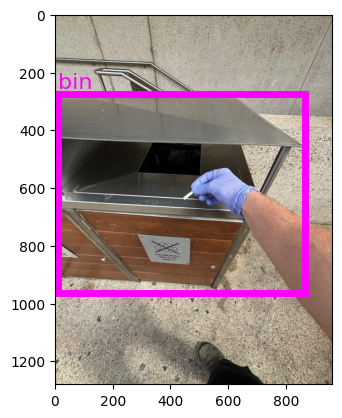

In [19]:
# Plot the box on the image
annotation_rect = Rectangle(xy=(real_box_coordinates.x_min, real_box_coordinates.y_min),
                            width=real_box_coordinates.width,
                            height=real_box_coordinates.height,
                            linewidth=5,
                            edgecolor=box_colour,
                            facecolor="none")

fig, ax = plt.subplots()
ax.add_patch(annotation_rect)
ax.text(x=real_box_coordinates.x_min,
        y=real_box_coordinates.y_min - 20,
        s=box_label_text,
        color=box_colour,
        fontsize=16)
ax.imshow(loaded_image);

Nice! That's a good looking box around the bin.

The goal of an object detection model for the Trashify project would be to replicate this box given the input image.

### Plotting a real image with boxes at different thresholds

Let's take our real image and its real bounding box and generate different bounding boxes at different thresholds so we can see what different IoU scoring boxes might look like.

To do so we can pass in our `real_box_coordinates` to the `generate_boxes_at_different_iou_thresholds()` function we created earlier.

In [20]:
# Take the reference box, generate many different boxes
real_image_generated_boxes_at_different_iou_thresholds = generate_boxes_at_different_iou_thresholds(reference_box=real_box_coordinates)

Synthetic boxes created from our real box coordinates, tick!

Now let's inspect them.

We'll create `x_max_plot_value` and `y_max_plot_value` variables to keep track of the size of the plots we want.

In [21]:
# Get max values from the generated boxes to adjust the plotting sizes
x_max_plot_value = 0
y_max_plot_value = 0

# Print out the generated boxes
for key, value in real_image_generated_boxes_at_different_iou_thresholds.items():
  print(f"IoU Threshold: {key}")
  for sub_key, sub_value in value.items():
    print(f"Box type: {sub_key} | Box: {sub_value[0]} | IoU score: {sub_value[1]}")
    x_max_plot_value = max(x_max_plot_value, sub_value[0].x_max)
    y_max_plot_value = max(y_max_plot_value, sub_value[0].y_max)
  print()

print(f"[INFO] Max x_max value: {x_max_plot_value}")
print(f"[INFO] Max y_max value: {y_max_plot_value}")

IoU Threshold: 0.5
Box type: reference | Box: Box(x_min=8.9, y_min=275.3, x_max=867.5, y_max=964.0) | IoU score: 1.0
Box type: grow | Box: Box(x_min=-134.1, y_min=132.3, x_max=1010.5, y_max=1107.0) | IoU score: 0.53
Box type: shift | Box: Box(x_min=272.9, y_min=275.3, x_max=1131.5, y_max=964.0) | IoU score: 0.53
Box type: shrink | Box: Box(x_min=112.9, y_min=379.3, x_max=763.5, y_max=860.0) | IoU score: 0.529

IoU Threshold: 0.55
Box type: reference | Box: Box(x_min=8.9, y_min=275.3, x_max=867.5, y_max=964.0) | IoU score: 1.0
Box type: grow | Box: Box(x_min=-111.1, y_min=155.3, x_max=987.5, y_max=1084.0) | IoU score: 0.58
Box type: shift | Box: Box(x_min=236.9, y_min=275.3, x_max=1095.5, y_max=964.0) | IoU score: 0.58
Box type: shrink | Box: Box(x_min=99.9, y_min=366.3, x_max=776.5, y_max=873.0) | IoU score: 0.58

IoU Threshold: 0.6
Box type: reference | Box: Box(x_min=8.9, y_min=275.3, x_max=867.5, y_max=964.0) | IoU score: 1.0
Box type: grow | Box: Box(x_min=-91.1, y_min=175.3, x_max

Boxes created, now let's see what they look like!

mkdir: images: File exists


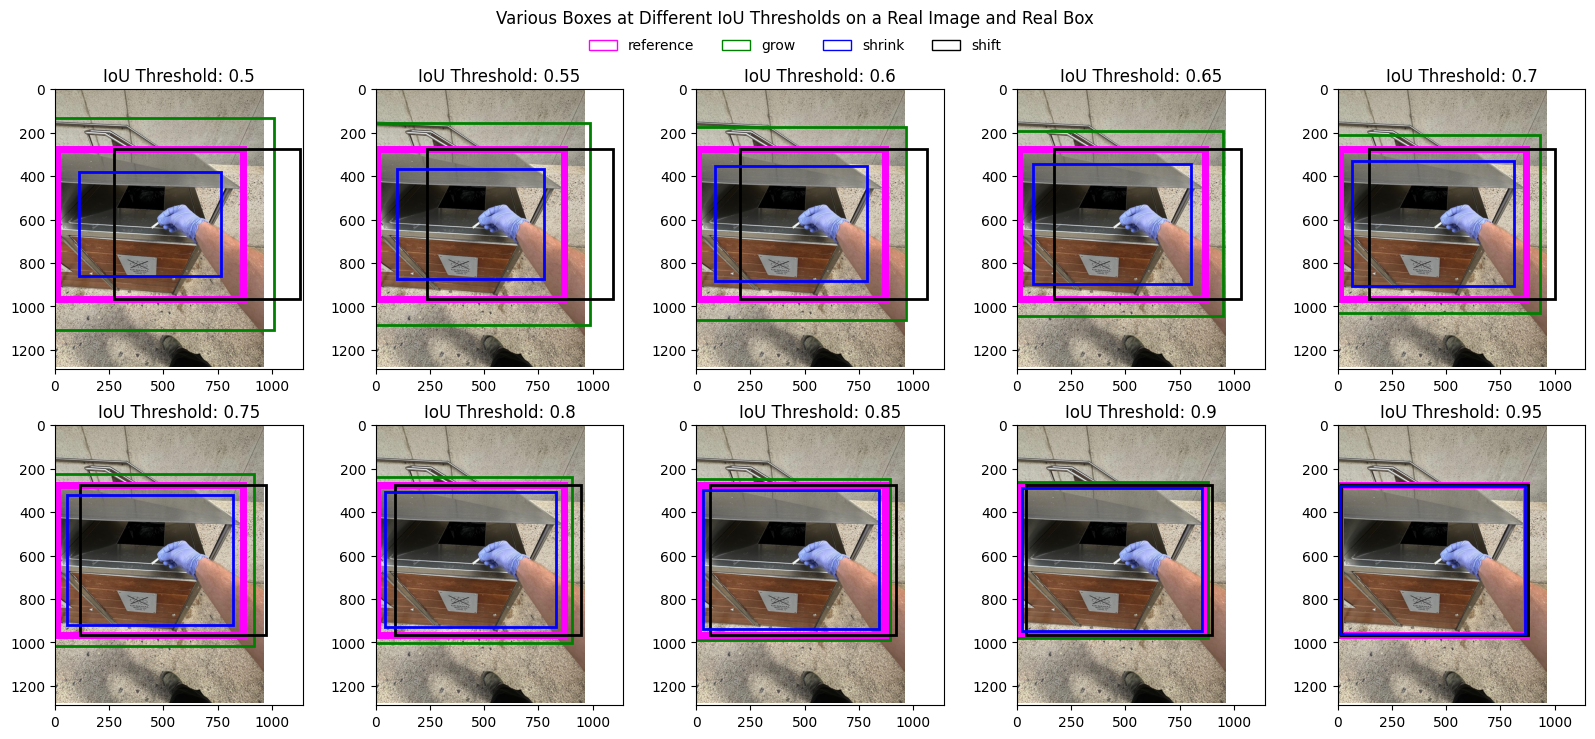

In [22]:
from matplotlib.patches import Patch

# Make a dict for box_type -> colour to plot
box_type_colour_dict = {"reference": box_colour,
                        "grow": "green",
                        "shrink": "blue",
                        "shift": "black"}

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
ax_flatten = ax.flatten()

for i, (iou_threshold, box_dict) in enumerate(real_image_generated_boxes_at_different_iou_thresholds.items()):
  ax_current = ax_flatten[i]

  # Plot the reference, grow, shift, shrink boxes
  for box_type, box_coordinates_and_iou in box_dict.items():
    box_colour = box_type_colour_dict[box_type] # e.g. "reference" -> "magenta"

    box_coordinates = box_coordinates_and_iou[0]

    # Plot the box on the current axis
    box_rectangle = Rectangle(xy=(box_coordinates.x_min, box_coordinates.y_min),
                              width=box_coordinates.width,
                              height=box_coordinates.height,
                              linewidth=5 if box_type == "reference" else 2,
                              facecolor="none",
                              edgecolor=box_colour)
    ax_current.add_patch(box_rectangle)

  # Set the target axis plot title
  ax_current.set_title(f"IoU Threshold: {iou_threshold}")

  # Set the size of the axis so the boxes are visible (they default to be 0 -> 1)
  # Since the generated boxes may exceed our image coordinates, we'll make the max dimension larger than the image itself (if necessary)
  ax_current.set_xlim(left=0, right=max(loaded_image.size[0], x_max_plot_value) + 10)
  ax_current.set_ylim(top=0, bottom=max(loaded_image.size[1], y_max_plot_value) + 10)

  # Add the target image
  ax_current.imshow(loaded_image)

# Create a patch legend at the base of the plot
legend_elements = [Patch(facecolor="none",
                         edgecolor=colour,
                         label=box_type)
                   for box_type, colour in box_type_colour_dict.items()]
fig.legend(handles=legend_elements,
           loc="lower center",
           ncols=len(box_type_colour_dict),
           bbox_to_anchor=(0.5, 0.91), # x, y percentage of plot (e.g. 0.5 = 50% x = halfway, 0.91 = 91% from bottom y)
           frameon=False) # no frame

plt.suptitle("Various Boxes at Different IoU Thresholds on a Real Image and Real Box")
# Optional: Save the figure before it gets plotted
!mkdir images
plt.savefig("images/multiple_boxes_with_iou_on_real_image.png")
plt.show()

It's a similar story to before.

With a real image though, it's easier to see how some IoU thresholds may be unacceptable from a performance stand point.

The boxes in at IoU threshold 0.5 are quite poor. I personally wouldn't enjoy using a model with level of box detection performance.

For the Trashify project, a model which creates boxes similar to the IoU threshold of 0.75 might be minimally viable.

However, for the best experience, we'd likely want a model that's capable of generating boxes similar to the IoU score of 0.8 and above.

Of course, it's easy to default to higher IoU being better but it's also good to inspect just what different levels of IoU look like.

Perhaps in the case of detecting manufacturing defects, you might a model capable of generated boxes with an IoU threshold of 0.9 and above.

## Part 4 - Speeding up our IoU calculation 100x

Our current `calculate_iou` function is fast for comparing two boxes.

But what if you had 1000s of boxes?

Well...

Let's just say... you might wanna go for a long walk or take a nap (though this isn't necessarily a bad thing).

Oh no...

For example, the COCO dataset has 1.5 million boxes.

And it's object standard practice for an object detection model to detect 100 boxes per image.

So if you had a project with 1000 images and 100 detection boxes per image, that's 100,000 total boxes.

We can speed our `calculate_iou` up by using NumPy and performing a batched IoU calculation.

We'll take advantage of NumPy's vectorization/[broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) to speed things up.

Broadcasting essentially enables a large number of calculations to be made in parallel on a NumPy array.

In our case, we want to make IoU score calucaltions across many boxes at once.

To do so, let's create a function `batch_iou` which takes in a list of prediction boxes and ground truth boxes and performs the IoU calculation across all of them simultaneously.

It'll return a matrix containing the IoU values of all prediction boxes versus the ground truth boxes.

This would allow us to work on a per sample basis.

For example, given an image with ground truth boxes and 100 prediction boxes, compare all predictions to the ground truths simultaneously.

We could then filter the matrix for various IoU threshold levels.

In [23]:
def batch_iou(pred_boxes, gt_boxes):
  """Calculate IoU between all pairs of predictions and ground truths

  Args:
    pred_boxes: numpy array of shape [n_preds, 4] with format [x_min, y_min, x_max, y_max]
    gt_boxes: numpy array of shape [n_gts, 4] with format [x_min, y_min, x_max, y_max]

  Returns:
    iou_matrix: numpy array of shape [n_preds, n_gts] with IoU values
  """
  # Handle empty arrays
  if pred_boxes.shape[0] == 0 or gt_boxes.shape[0] == 0:
    return np.zeros((pred_boxes.shape[0], gt_boxes.shape[0]))

  # Expand dimensions to enable broadcasting
  pred_boxes = pred_boxes[:, np.newaxis, :] # Shape: [n_preds, 1, 4]
  gt_boxes = gt_boxes[np.newaxis, :, :] # shape: [1, n_preds, 4]

  # Calculate intersection coordinates
  # Get the max of the mins
  x_min = np.maximum(pred_boxes[:, :, 0], gt_boxes[:, :, 0]) # <- this uses broadcasting to speed up calculations
  y_min = np.maximum(pred_boxes[:, :, 1], gt_boxes[:, :, 1])

  # Get the min of the maxs
  x_max = np.minimum(pred_boxes[:, :, 2], gt_boxes[:, :, 2])
  y_max = np.minimum(pred_boxes[:, :, 3], gt_boxes[:, :, 3])

  # Caculate intersection areas
  width = np.maximum(0, x_max - x_min)
  height = np.maximum(0, y_max - y_min)
  intersection = width * height

  # Calcualte areas
  # Area of boxes = (x_max - x_min) * (y_max - y_min)
  pred_areas = (pred_boxes[:, :, 2] - pred_boxes[:, :, 0]) * (pred_boxes[:, :, 3] - pred_boxes[:, :, 1])
  gt_areas = (gt_boxes[:, :, 2] - gt_boxes[:, :, 0]) * (gt_boxes[:, :, 3] - gt_boxes[:, :, 1])

  # Calculate union area
  union = pred_areas + gt_areas - intersection

  # Calculate IoU
  iou_matrix = intersection / union

  return iou_matrix

Wonderful!

Now our `batch_iou` function isn't limited to only comparing one box to another, it can do *many* to *many* boxes.

Let's create some ground truth and prediction boxes in the form of NumPy arrays.

In [24]:
# Use a random seed for reproducibility
np.random.seed(42)

# Create random ground truths with 5 boxes and 100 preds
gt_boxes = np.random.rand(5, 4) # generate 5 ground truth boxes with 4 coordinates
pred_boxes = np.random.rand(100, 4) # generate 100 prediction truth boxes with 4 coordinates

# Quick addition to ensure all boxes obey x_min < x_max and y_min < y_max
gt_boxes[:, 2] += 1 # increase x_max
gt_boxes[:, 3] += 1 # increase y_max

pred_boxes[:, 2] += 1 # increase x_max
pred_boxes[:, 3] += 1 # increase y_max

print(f"[INFO] Ground truth boxes:")
print(gt_boxes)
print()
print(f"[INFO] First 10 prediction boxes:")
print(pred_boxes[:10, :])

[INFO] Ground truth boxes:
[[0.37454012 0.95071431 1.73199394 1.59865848]
 [0.15601864 0.15599452 1.05808361 1.86617615]
 [0.60111501 0.70807258 1.02058449 1.96990985]
 [0.83244264 0.21233911 1.18182497 1.18340451]
 [0.30424224 0.52475643 1.43194502 1.29122914]]

[INFO] First 10 prediction boxes:
[[0.61185289 0.13949386 1.29214465 1.36636184]
 [0.45606998 0.78517596 1.19967378 1.51423444]
 [0.59241457 0.04645041 1.60754485 1.17052412]
 [0.06505159 0.94888554 1.96563203 1.80839735]
 [0.30461377 0.09767211 1.68423303 1.44015249]
 [0.12203823 0.49517691 1.03438852 1.9093204 ]
 [0.25877998 0.66252228 1.31171108 1.52006802]
 [0.54671028 0.18485446 1.96958463 1.77513282]
 [0.93949894 0.89482735 1.59789998 1.92187424]
 [0.0884925  0.19598286 1.04522729 1.32533033]]


Now let's use our `batch_iou` function to calculate an IoU matrix comparing the `pred_boxes` to the `gt_boxes`.



In [25]:
# Create IoU matrix
iou_matrix = batch_iou(pred_boxes=pred_boxes,
                       gt_boxes=gt_boxes)
iou_matrix.shape

(100, 5)

Woah! That seemed quick!

We'll get to time measurements later on.

For now, let's make sure the IoU calculations from our `batch_iou` function are the same as a single IoU calcuation with our `caculate_iou` function.

Because the output of `batch_iou` is a matrix with dimensions `(n_preds, n_gts)`, we can find the IoU for a target box by indexing on the matrix.

For example, if we want the IoU score of prediction at index `0` and ground truth at index `0` (the first object in each `pred_boxes` and `gt_boxes` array), we can use `iou_matrix[0, 0]`.

Or if we wanted the prediction at index `31` and the ground truth at index `3` we could use `iou_matrix[31, 3]`.

Let's get the first prediction and ground truth indexes, turn them into a `Box` dataclass and then compare them with `calculate_iou`.

In [26]:
# Get first ground truth and pred box
gt_0 = gt_boxes[0]
pred_0 = pred_boxes[0]
print(f"[INFO] Ground truth index 0 array: {gt_0}")
print(f"[INFO] Prediction index 0 array: {pred_0}")
print()

# Turn the NumPy arrays into a Box dataclass (for use with our calculate_iou function)
gt_box_0 = Box(x_min=gt_0[0],
               y_min=gt_0[1],
               x_max=gt_0[2],
               y_max=gt_0[3])

pred_box_0 = Box(x_min=pred_0[0],
                 y_min=pred_0[1],
                 x_max=pred_0[2],
                 y_max=pred_0[3])
print(f"[INFO] Ground truth Box: {gt_box_0}")
print(f"[INFO] Prediction Box: {pred_box_0}")
print()

# Calculate the IoU
iou_0_0 = calculate_iou(box_1=pred_box_0, box_2=gt_box_0, return_intersection_box=False)
print(f"[INFO] IoU: {iou_0_0}")

[INFO] Ground truth index 0 array: [0.37454012 0.95071431 1.73199394 1.59865848]
[INFO] Prediction index 0 array: [0.61185289 0.13949386 1.29214465 1.36636184]

[INFO] Ground truth Box: Box(x_min=np.float64(0.3745401188473625), y_min=np.float64(0.9507143064099162), x_max=np.float64(1.731993941811405), y_max=np.float64(1.5986584841970366))
[INFO] Prediction Box: Box(x_min=np.float64(0.6118528947223795), y_min=np.float64(0.13949386065204183), x_max=np.float64(1.2921446485352182), y_max=np.float64(1.3663618432936917))

[INFO] IoU: 0.198


Now to make sure our numbers line up, let's compare the IoU score from our `calculate_iou` function to the IoU score for the box at `[0, 0]` (prediction index `0`, ground truth index `0`) in our `iou_matrix`.

In [27]:
iou_0_0_from_matrix = float(round(iou_matrix[0, 0], 3))
print(f"[INFO] IoU from matrix: {iou_0_0_from_matrix}")

[INFO] IoU from matrix: 0.198


Are they the same?

In [28]:
print(f"IoU from calculate_iou and batch_iou are the same? {iou_0_0 == iou_0_0_from_matrix}")

IoU from calculate_iou and batch_iou are the same? True


Woohoo!

Looks like our `calculate_iou` and `batch_iou` functions are outputing the same IoU values for a given pair of boxes.

Except under the hood the `batch_ioi` function is *much* faster.

Don't believe me?

Let's run a simulation across different numbers of samples and measure the calculation time for each function.

### Running a speed test across different numbers of samples

To run our speed test we'll create a list containing different numbers of image samples (e.g. 1, 10, 100, 1000...).

Then we'll test how long it takes for each IoU function, `calculate_iou` and `batch_iou` to calculate the IoU scores of our `pred_boxes` (100 preds per sample) and `gt_boxes` (5 ground truth boxes per sample).


In [29]:
%%time
import time

NUM_SAMPLES_LIST = [1, 10, 100, 1000, 10000]
results_dict = {}

for NUM_SAMPLES in NUM_SAMPLES_LIST:

  # Perform IoU calculation in batch format
  start_time_batch_iou = time.time()
  for _ in range(NUM_SAMPLES):
    batch_iou(pred_boxes=pred_boxes, gt_boxes=gt_boxes)
  end_time_batch_iou = time.time()
  total_time_batch_iou = round(end_time_batch_iou - start_time_batch_iou, 3)

  print(f"[INFO] Time taken for {NUM_SAMPLES} samples using batched IoU calculations: {total_time_batch_iou}s")

  # Perform IoU calculation one by one
  start_time_one_by_one_iou = time.time()
  for _ in range(NUM_SAMPLES):
    for gt_box in gt_boxes:
      for pred_box in pred_boxes:

        # Turn boxes into Box instances
        box_1 = Box(x_min=gt_box[0],
                    y_min=gt_box[1],
                    x_max=gt_box[2],
                    y_max=gt_box[3])

        box_2 = Box(x_min=pred_box[0],
                    y_min=pred_box[1],
                    x_max=pred_box[2],
                    y_max=pred_box[3])

        calculate_iou(box_1=box_1,
                      box_2=box_2,
                      return_intersection_box=False)
  end_time_one_by_one_iou = time.time()
  total_time_one_by_one_iou = round(end_time_one_by_one_iou - start_time_one_by_one_iou, 5)

  print(f"[INFO] Time taken for {NUM_SAMPLES} samples using one by one IoU calculations: {total_time_one_by_one_iou}s")

  # Calculate the total number of boxes calculated on
  total_boxes = len(pred_boxes) * len(gt_boxes) * NUM_SAMPLES
  print(f"[INFO] Total boxes calculated on (per function): {total_boxes}")
  print()

  # Save the results to a dictionary
  times = {"batch_iou_time": total_time_batch_iou,
           "one_by_one_iou_time": total_time_one_by_one_iou}

  results_dict[NUM_SAMPLES] = times

[INFO] Time taken for 1 samples using batched IoU calculations: 0.0s
[INFO] Time taken for 1 samples using one by one IoU calculations: 0.00181s
[INFO] Total boxes calculated on (per function): 500

[INFO] Time taken for 10 samples using batched IoU calculations: 0.0s
[INFO] Time taken for 10 samples using one by one IoU calculations: 0.01475s
[INFO] Total boxes calculated on (per function): 5000

[INFO] Time taken for 100 samples using batched IoU calculations: 0.001s
[INFO] Time taken for 100 samples using one by one IoU calculations: 0.14879s
[INFO] Total boxes calculated on (per function): 50000

[INFO] Time taken for 1000 samples using batched IoU calculations: 0.012s
[INFO] Time taken for 1000 samples using one by one IoU calculations: 1.47221s
[INFO] Total boxes calculated on (per function): 500000

[INFO] Time taken for 10000 samples using batched IoU calculations: 0.118s
[INFO] Time taken for 10000 samples using one by one IoU calculations: 14.91115s
[INFO] Total boxes calcula

Woah! Looks like the batch IoU calculations perform far quicker than the one by one calculations.

Let's write some code to confirm which is faster and by how much.

In [30]:
# Find the faster times for each number of samples
for num_samples, results in results_dict.items():
  min_time = min(results.values())
  for key, value in results.items():
    if value == min_time:
      faster_key = key
    else:
      slower_key = key

  print(f"[INFO] Using {faster_key} for {num_samples} samples is {round(times[slower_key] / times[faster_key], 2)}x faster than using {slower_key}")

[INFO] Using batch_iou_time for 1 samples is 126.37x faster than using one_by_one_iou_time
[INFO] Using batch_iou_time for 10 samples is 126.37x faster than using one_by_one_iou_time
[INFO] Using batch_iou_time for 100 samples is 126.37x faster than using one_by_one_iou_time
[INFO] Using batch_iou_time for 1000 samples is 126.37x faster than using one_by_one_iou_time
[INFO] Using batch_iou_time for 10000 samples is 126.37x faster than using one_by_one_iou_time


Ok ok...

It's clear `batch_iou` is the winner here.

On Google Colab, I noticed a 100x+ speed up using `batch_iou` versus `calculate_iou` (speedup factors will depend on the hardware you're using).

How about we visualize the results in a plot?

First, we'll check out our `results_dict`.

In [31]:
results_dict

{1: {'batch_iou_time': 0.0, 'one_by_one_iou_time': 0.00181},
 10: {'batch_iou_time': 0.0, 'one_by_one_iou_time': 0.01475},
 100: {'batch_iou_time': 0.001, 'one_by_one_iou_time': 0.14879},
 1000: {'batch_iou_time': 0.012, 'one_by_one_iou_time': 1.47221},
 10000: {'batch_iou_time': 0.118, 'one_by_one_iou_time': 14.91115}}

Beautiful!

Now let's write some code to visualize our results.

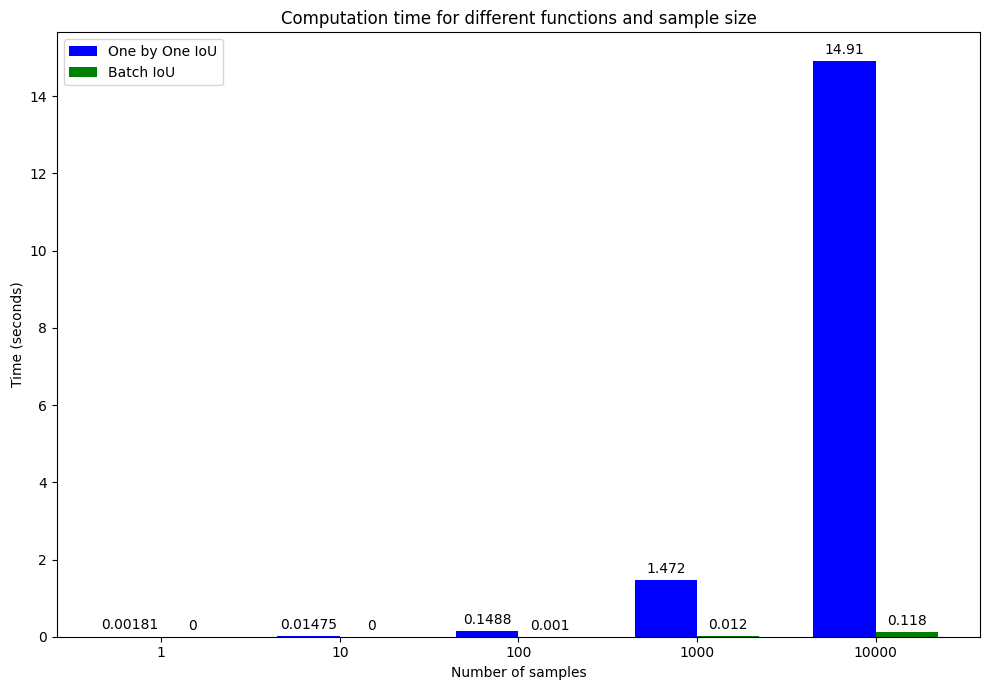

In [32]:
import matplotlib.pyplot as plt

# Get data for plot
x_values = list(results_dict.keys())
one_by_one_times = [value["one_by_one_iou_time"] for value in results_dict.values()]
batch_times = [value["batch_iou_time"] for value in results_dict.values()]

# Create x-axis positions
x_positions = np.arange(len(x_values))
width = 0.35 # width of the columns

# Create figure and bars
fig, ax = plt.subplots(figsize=(10, 7))
bars_one_by_one = ax.bar(x=x_positions - width/2,
                         height=one_by_one_times,
                         width=width,
                         label="One by One IoU",
                         color="blue")
bars_batch = ax.bar(x=x_positions + width/2,
                    height=batch_times,
                    width=width,
                    label="Batch IoU",
                    color="green")

# Add times to the top of each column
for bar in bars_one_by_one + bars_batch:
  height_of_bar = bar.get_height()
  ax.annotate(f"{height_of_bar:.4g}", # :.4g = use 4 significant figures total, :.4f = use 4 significant figures after the decimal
              xy=(bar.get_x()+ bar.get_width()/2, height_of_bar),
              xytext=(0, 3),
              textcoords="offset points",
              ha="center",
              va="bottom")

# Setup figure attributes
ax.set_xticks(x_positions)
ax.set_xticklabels([str(x) for x in x_values])
ax.set_xlabel("Number of samples")
ax.set_ylabel("Time (seconds)")
ax.set_title("Computation time for different functions and sample size")
ax.legend()
fig.tight_layout()
plt.show()

## Summary

What an effort!

Consider IoU learned about!

Let's summarize:

* IoU = a metric which compares how much two boxes (e.g. a prediction box and a ground truth box) overlap
* Higher IoU = better, a value of 1.0 is a perfect overlap where as a value of 0.0 is no overlap at all
* It's good to visualize different levels of IoU thresholds on your images so you know what different kinds of boxes look like (e.g. your use case may call for a higher IoU than standard metrics consolidate for)
* For faster calculations, if you can, batch them with NumPy, you might see speedups of 100x or more

## Extensions

* For more on the topic of bounding boxes and the different formats they come in, see [*A Guide to Bounding Box Formats and How to Draw Them*](https://www.learnml.io/posts/a-guide-to-bounding-box-formats/).
* For an end-to-end example of building an object detection model and customizing it for your own dataset, see the [*Object Detection with Hugging Face Transformers Tutorial*](https://www.learnhuggingface.com/notebooks/hugging_face_object_detection_tutorial).